# Permeability via LBM flow solver

This example computes the absolute permeability of a PoreSpy-generated porous medium using the D3Q19 MRT lattice Boltzmann solver, and visualizes the velocity field as streamlines.

In [1]:
import numpy as np
import porespy as ps
import matplotlib.pyplot as plt
import poromics

## Generate a porous medium image

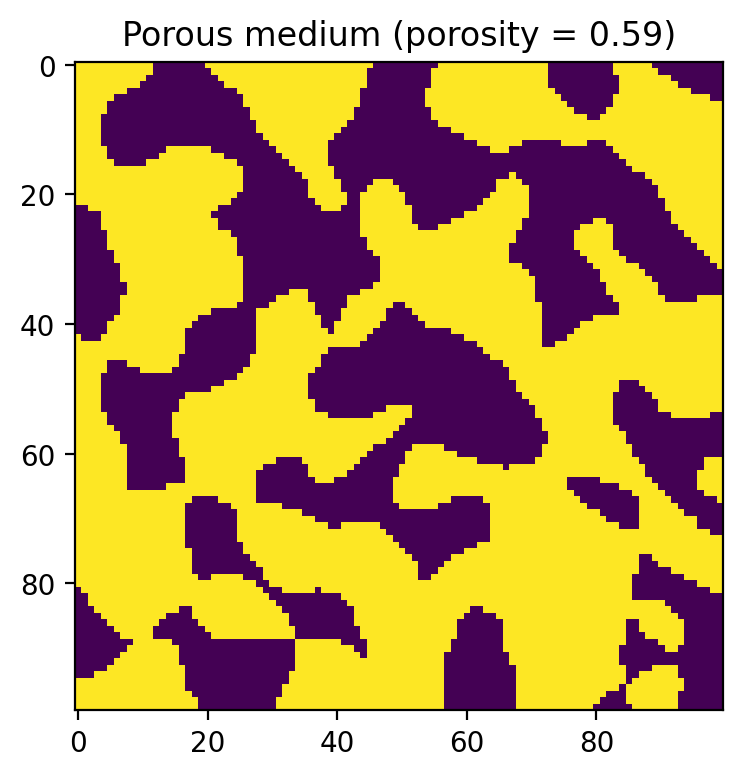

In [2]:
im = ps.generators.blobs(shape=[100, 100, 1], porosity=0.6, blobiness=0.5, seed=42)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(im[:, :, 0], cmap="viridis", interpolation="nearest")
ax.set_title(f"Porous medium (porosity = {im.mean():.2f})")
plt.tight_layout()

## Compute permeability

We use a kinematic viscosity of $10^{-6}$ m²/s (water at ~20 °C) and a voxel size of 1 µm.

In [3]:
result = poromics.permeability_lbm(im, axis=1, nu=1e-6, voxel_size=1e-6)
print(result)
print(f"Permeability: {result.k_m2:.4e} m² ({result.k_mD:.2f} mD)")
print(f"Darcy velocity: {result.u_darcy:.4e} m/s")
print(f"Pore velocity: {result.u_pore:.4e} m/s")

[Taichi] version 1.7.4, llvm 15.0.7, commit b4b956fd, osx, python 3.12.9


[I 03/08/26 11:48:51.887 19840166] [shell.py:_shell_pop_print@23] Graphical python shell detected, using wrapped sys.stdout


Output()

[Taichi] Starting on arch=metal


PermeabilityResult(k_m2=2.826718e-13, k_mD=286.4172, axis=1)
Permeability: 2.8267e-13 m² (286.42 mD)
Darcy velocity: 3.3921e-04 m/s
Pore velocity: 6.8513e-04 m/s


## Visualize the velocity field

Since our image is quasi-2D (shape 100×100×1), we can visualize the velocity as streamlines on the z=0 slice.

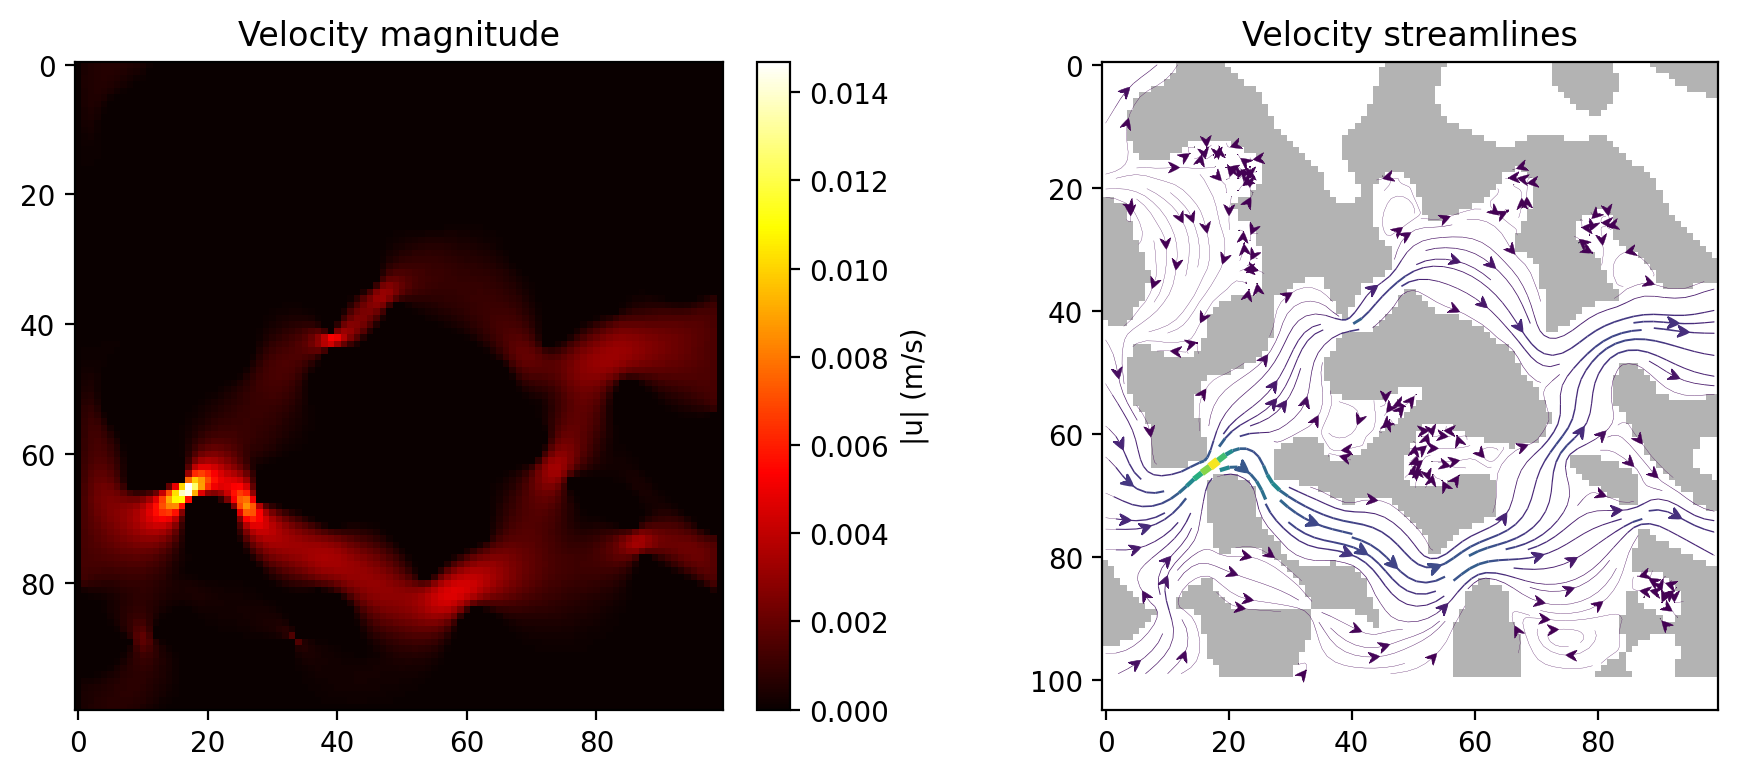

In [4]:
v = result.velocity[:, :, 0, :]  # z=0 slice
speed = np.sqrt(v[:, :, 0]**2 + v[:, :, 1]**2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Velocity magnitude
cax = axes[0].imshow(speed, cmap="hot", interpolation="nearest")
axes[0].set_title("Velocity magnitude")
fig.colorbar(cax, ax=axes[0], fraction=0.046, pad=0.04, label="|u| (m/s)")

# Streamlines with varying line width
nx, ny = im.shape[0], im.shape[1]
X, Y = np.meshgrid(np.arange(ny), np.arange(nx))
lw = 3 * speed / speed.max() + 0.1
axes[1].imshow(im[:, :, 0], cmap="gray", interpolation="nearest", alpha=0.3)
axes[1].streamplot(X, Y, v[:, :, 1], v[:, :, 0], color=speed,
                   cmap="viridis", density=2, linewidth=lw,
                   arrowstyle="fancy")
axes[1].set_title("Velocity streamlines")

plt.tight_layout()

## Using the low-level solver

For more control, use `TransientFlow` directly.

In [5]:
from poromics.simulation import TransientFlow

solver = TransientFlow(im, axis=1, nu=1e-6, voxel_size=1e-6)
solver.run(n_steps=50_000, tol=1e-3)

print(f"Converged: {solver.converged}")
print(f"Iterations: {solver.n_iterations}")
print(f"Physical time step: {solver.dt:.2e} s")

Converged: True
Iterations: 6001
Physical time step: 1.67e-07 s


The `velocity` and `pressure` properties return fields in physical units:

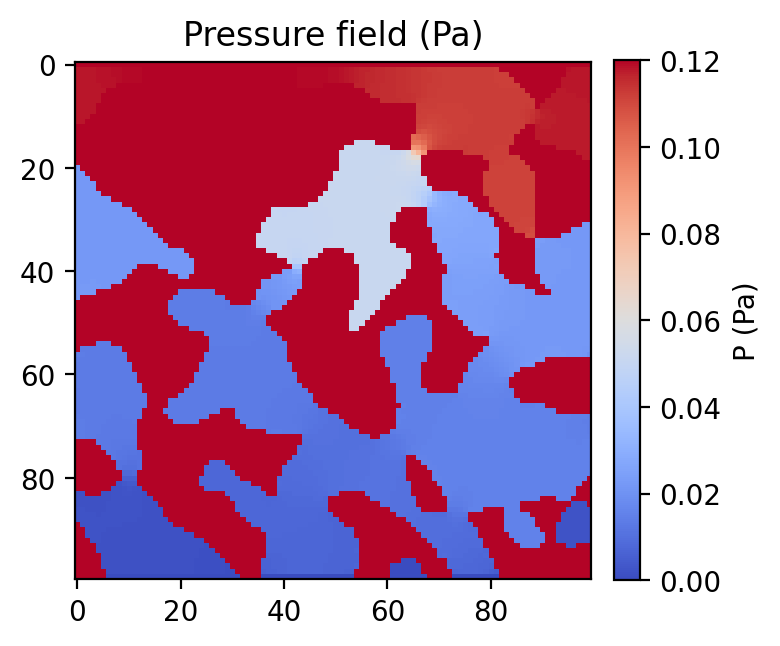

In [6]:
v = solver.velocity   # m/s, shape (nx, ny, nz, 3)
P = solver.pressure   # Pa (gauge), shape (nx, ny, nz)

fig, ax = plt.subplots(figsize=(4, 4))
cax = ax.imshow(P[:, :, 0].T, cmap="coolwarm", interpolation="nearest")
ax.set_title("Pressure field (Pa)")
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04, label="P (Pa)")
plt.tight_layout()